## 03 Procesamiento de Data

1. Revisión de datos (primeros 5 y ultimos 5)
2. Eliminamos las columnas irrelevantes para el análisis.
3. Ingeniería de atributos (Pandemia)
4. Eliminación de meses de "Pandemia"
5. Separacion de variables categoricas y numericas
6. Variables numéricas
   1. Convertimos a log1p las variables con asimetría positiva.
   2. Identificación de Outliers (IQR). 
   3. Imputación de Nulos mediante Random forest regresor
   4. Medimos la correlación de varibales numéricas
   5. Devolvemos las variables a su valor original.
7. Juntamos las variables numéricas imputadas con las vairables Categóricas
8. Guardado de datos preprocesados.

In [1]:
import pandas as pd

data_row = pd.read_csv('../Data/Row/Flujo vehicular registrado en peajes_2014-2025_II.csv', encoding='latin-1')

df_prep = data_row.copy()

df_prep.head()

,ID,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,NOMBRE_PEAJE,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,...,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
0,0,Concesionado,22PE5NACS1,San Martín,Aguas Claras,2099,8070.0,0,2586.0,2374.0,...,8.0,10169,328.0,9515,306.9,19684,635.0,2014,1,201401
1,1,Concesionado,04PE1SCAM1,Arequipa,Camaná,0,24644.0,0,6502.0,4622.0,...,213.0,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401
2,2,Concesionado,21PE3SCRO1,Puno,Caracoto,33643,82139.0,5797,17981.0,5307.0,...,12.0,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401
3,3,Concesionado,12PE3NCRA1,Junín,Casaracra-Concesión,10,46944.0,0,16981.0,18585.0,...,135.0,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401
4,4,Concesionado,08PE3SCSC1,Cusco,Ccasacancha (Huillque),0,23831.0,0,4709.0,3941.0,...,95.0,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401


In [2]:
df_prep.columns

Index(['ID', 'ADMINIST', 'CODIGO_PEAJE', 'DEPARTAMENTO', 'NOMBRE_PEAJE',
       'VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS_TAR_DIF',
       'VEH_PESADOS__2E', 'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E',
       'VEH_PESADOS_6E', 'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL',
       'VEH_LIGEROS_IMD', 'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL',
       'VEH_IMD', 'ANIO', 'MES', 'PERIODO'],
      dtype='object')

In [3]:
# Eliminamos las oclumnas que no nos sirven
df_prep.drop(columns= ['ID', 'NOMBRE_PEAJE', 'VEH_LIGEROS_TOTAL',
       'VEH_LIGEROS_IMD', 'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL',
       'VEH_IMD'] , axis=1, inplace=True)

df_prep.head(5)

,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,ANIO,MES,PERIODO
0,Concesionado,22PE5NACS1,San Martín,2099,8070.0,0,2586.0,2374.0,720.0,315.0,3512.0,8.0,2014,1,201401
1,Concesionado,04PE1SCAM1,Arequipa,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,2014,1,201401
2,Concesionado,21PE3SCRO1,Puno,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,2014,1,201401
3,Concesionado,12PE3NCRA1,Junín,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,2014,1,201401
4,Concesionado,08PE3SCSC1,Cusco,0,23831.0,0,4709.0,3941.0,447.0,769.0,3945.0,95.0,2014,1,201401


In [4]:
# Feature Enginnering
df_prep['Pandemia'] = df_prep['PERIODO'].apply(lambda x: 1 if x in {202003, 202004, 202005, 202006, 202007} else 0 )


df_prep.head(5)

,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,ANIO,MES,PERIODO,Pandemia
0,Concesionado,22PE5NACS1,San Martín,2099,8070.0,0,2586.0,2374.0,720.0,315.0,3512.0,8.0,2014,1,201401,0
1,Concesionado,04PE1SCAM1,Arequipa,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,2014,1,201401,0
2,Concesionado,21PE3SCRO1,Puno,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,2014,1,201401,0
3,Concesionado,12PE3NCRA1,Junín,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,2014,1,201401,0
4,Concesionado,08PE3SCSC1,Cusco,0,23831.0,0,4709.0,3941.0,447.0,769.0,3945.0,95.0,2014,1,201401,0


In [5]:
# Eliminamos del analisis el tiempo de periodo de la pandemia
df_filter = df_prep[df_prep['Pandemia'] != 1]

In [6]:
# Separacion de variables por numericas y categoricas

df_prep_num = df_filter.select_dtypes(include=['int64', 'float64','number'])
df_prep_cat = df_filter.select_dtypes(include=['object', 'category'])

### Trabajamos las variables numéricas

In [7]:
df_prep_num

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,ANIO,MES,PERIODO,Pandemia
0,2099,8070.0,0,2586.0,2374.0,720.0,315.0,3512.0,8.0,2014,1,201401,0
1,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,2014,1,201401,0
2,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,2014,1,201401,0
3,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,2014,1,201401,0
4,0,23831.0,0,4709.0,3941.0,447.0,769.0,3945.0,95.0,2014,1,201401,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10776,660,3609.0,0,808.0,603.0,605.0,2553.0,859.0,3.0,2025,6,202506,0
10777,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,2025,6,202506,0
10778,0,31078.0,0,3209.0,965.0,290.0,221.0,489.0,4.0,2025,6,202506,0
10779,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,2025,6,202506,0


/tmp/ipykernel_22333/887561714.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_prep_num[atribute], fill=True)


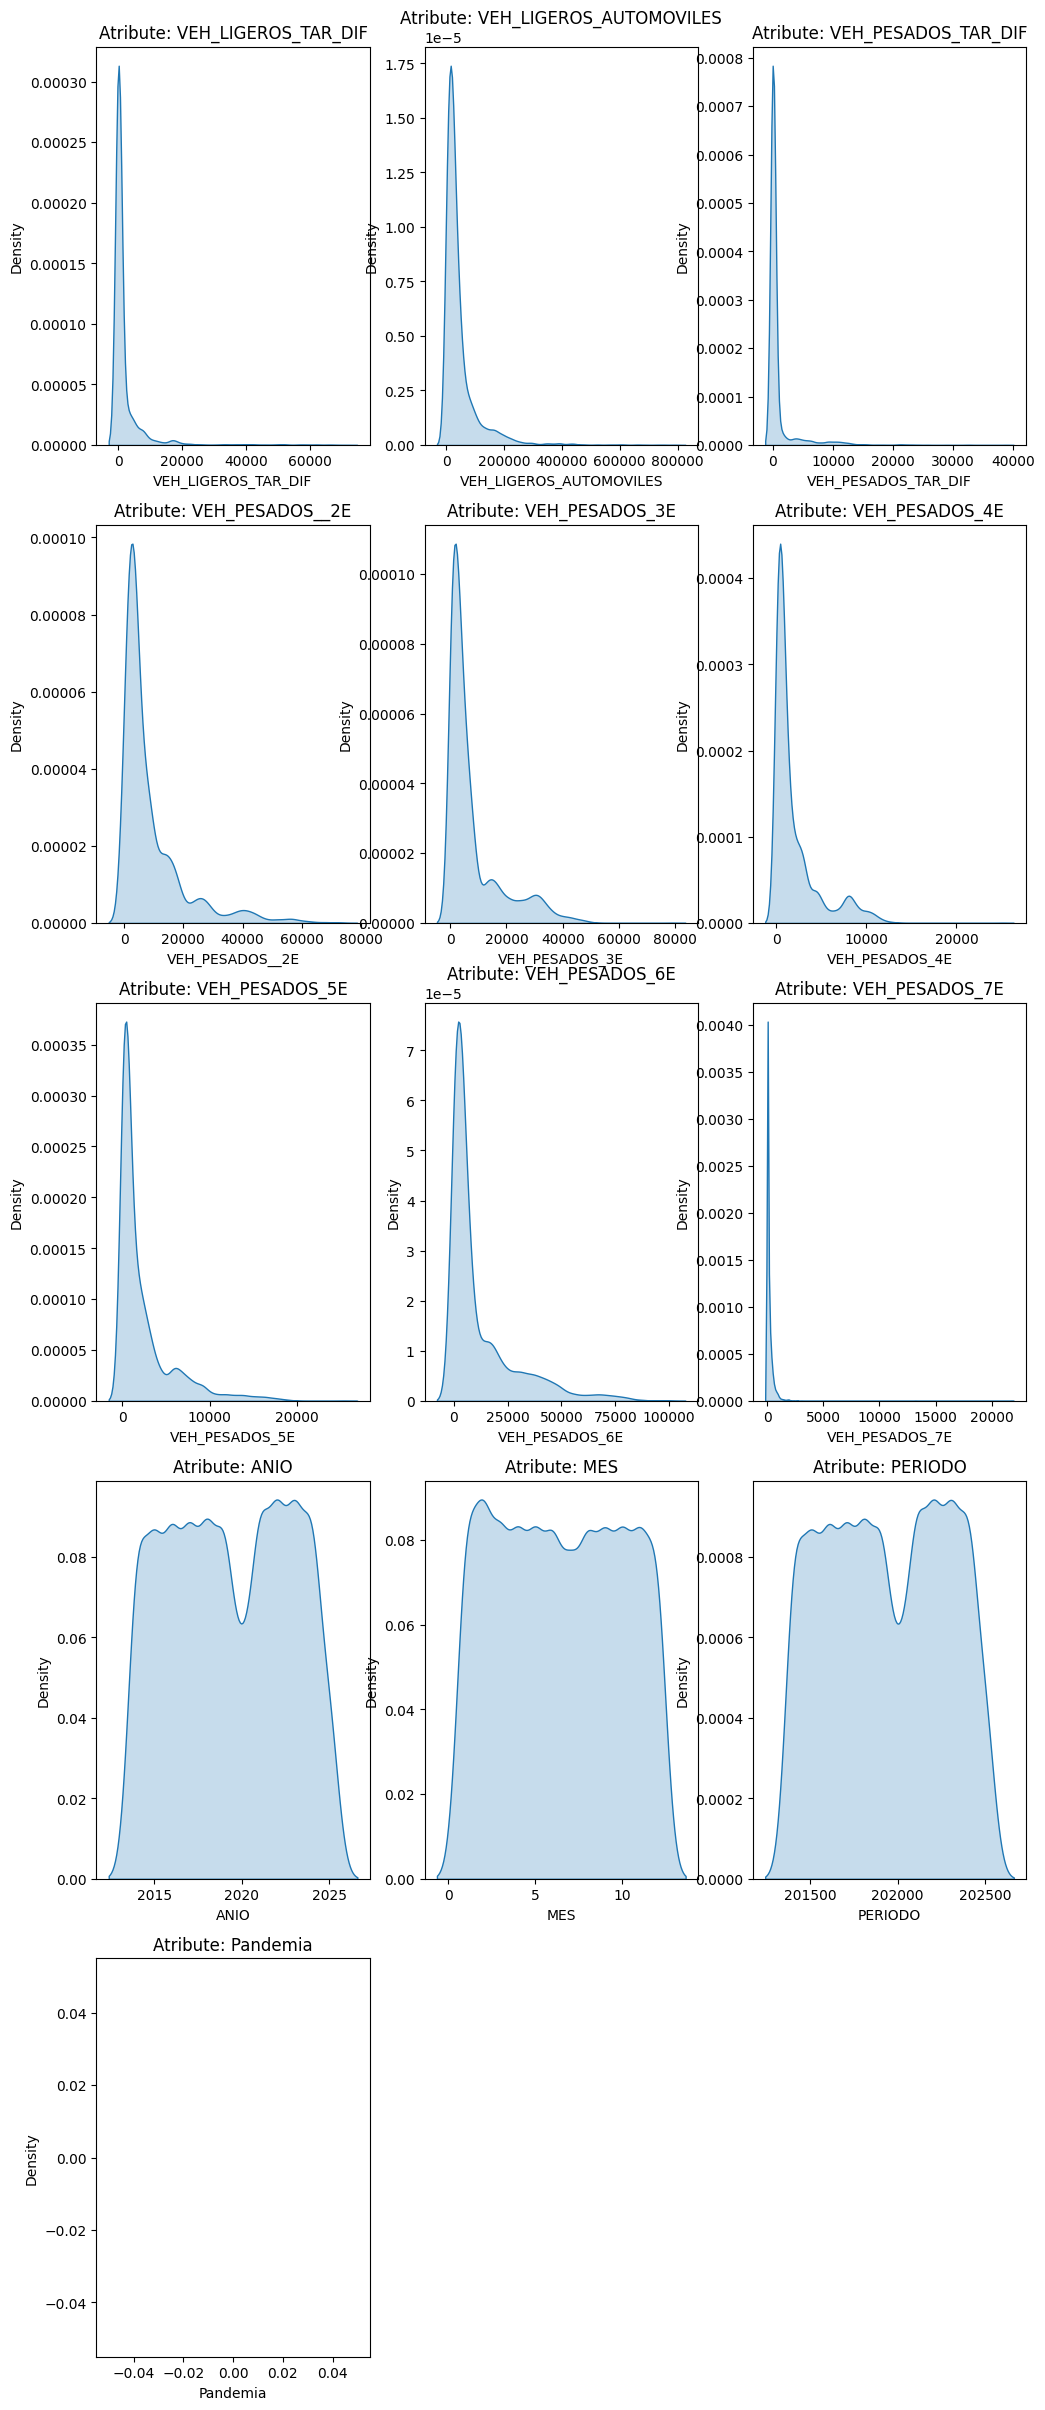

In [8]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3

n_vars = len(df_prep_num.columns)
n_rows = math.ceil(n_vars / n_cols)

plt.figure(figsize=(12, n_rows*6))

for i, atribute in enumerate(df_prep_num.columns):
    plt.subplot(n_rows, n_cols, i+1)
    sns.kdeplot(df_prep_num[atribute], fill=True)

    plt.title(f'Atribute: {atribute}')

In [9]:
df_prep_num.columns

Index(['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS_TAR_DIF',
       'VEH_PESADOS__2E', 'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E',
       'VEH_PESADOS_6E', 'VEH_PESADOS_7E', 'ANIO', 'MES', 'PERIODO',
       'Pandemia'],
      dtype='object')

In [10]:
import numpy as np

columnas_a_normalizar = ['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS_TAR_DIF',
       'VEH_PESADOS__2E', 'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E',
       'VEH_PESADOS_6E', 'VEH_PESADOS_7E']

df_prep_num_log = df_prep_num.copy()

for col in columnas_a_normalizar:
    df_prep_num_log[col] = df_prep_num[col].apply(np.log1p)

/tmp/ipykernel_22333/4200661542.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_prep_num_log[atribute], fill=True)


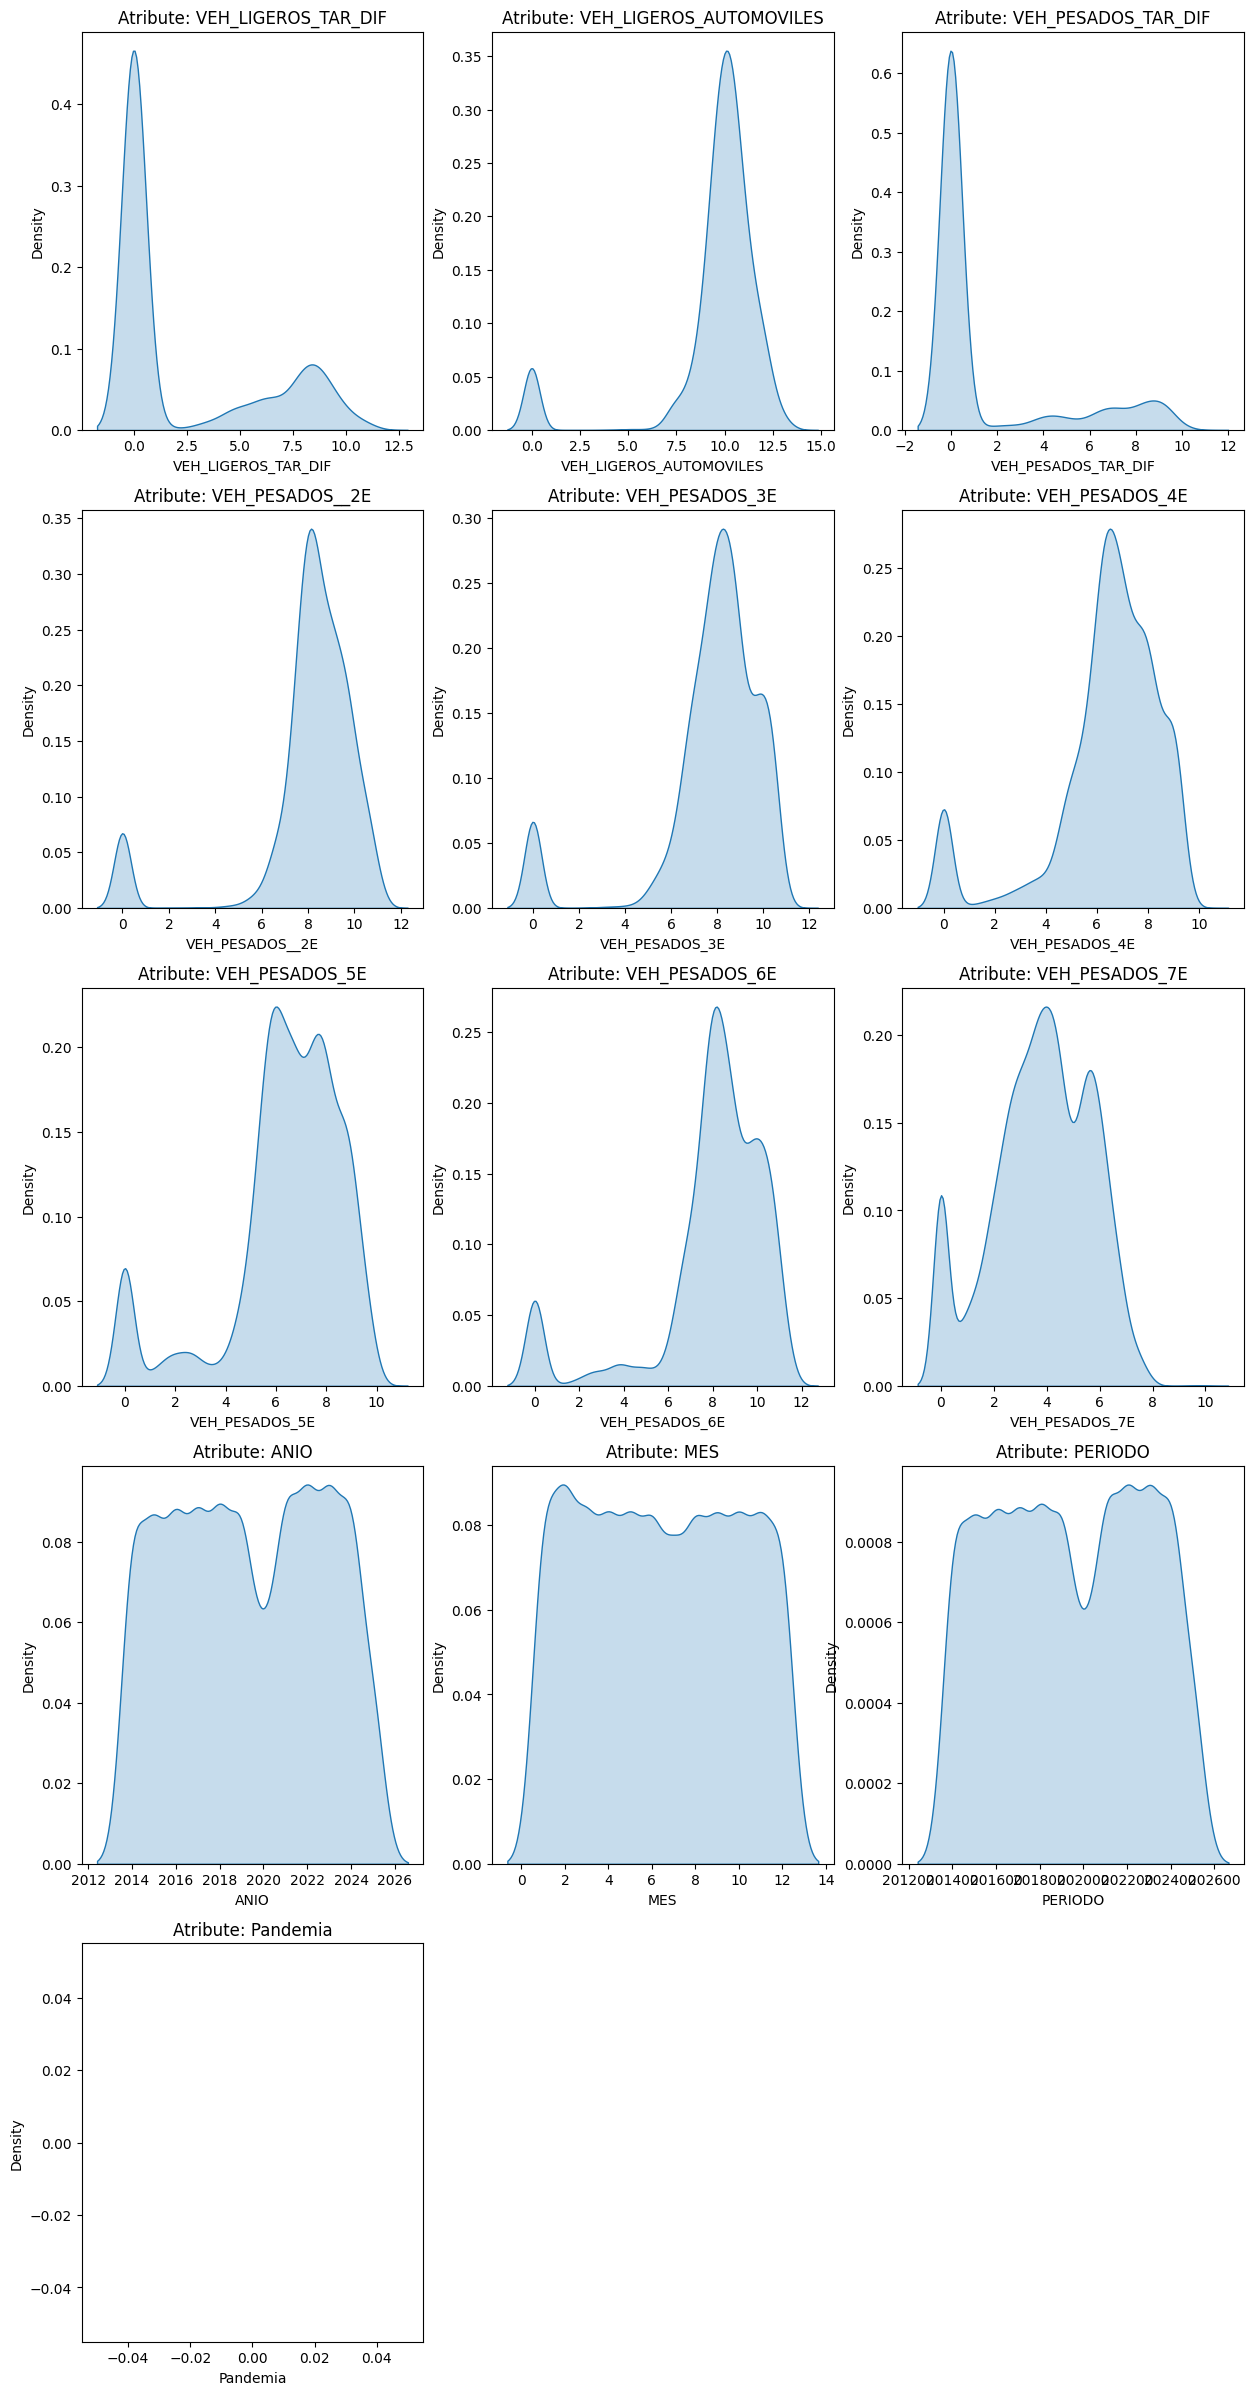

In [11]:
#Graficamos para verificar el cambio

n_cols = 3

n_vars = len(df_prep_num_log.columns)
n_rows = math.ceil( n_vars / n_cols)

plt.figure(figsize=(15, n_rows*6))

for i, atribute in enumerate(df_prep_num_log.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.kdeplot(df_prep_num_log[atribute], fill=True)
    plt.title(f'Atribute: {atribute}')

In [12]:
# Identificamos outliers numéricos

# Podemos usar z-score (Cuando tenemos gran cantidad de datos y una distribución normal) o iqr (Cuando la cantida de datos es pqueñay tiene una tendencia hacia un lado.)
Q1 = df_prep_num_log.quantile(0.25)
Q3 = df_prep_num_log.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

df_prep_filtered_num = df_prep_num_log[(df_prep_num_log > lower_bound) & (df_prep_num_log < upper_bound)]

df_prep_filtered_num.count()


VEH_LIGEROS_TAR_DIF        10386
VEH_LIGEROS_AUTOMOVILES     9577
VEH_PESADOS_TAR_DIF            0
VEH_PESADOS__2E             9703
VEH_PESADOS_3E              9714
VEH_PESADOS_4E              9615
VEH_PESADOS_5E              9511
VEH_PESADOS_6E              9423
VEH_PESADOS_7E             10376
ANIO                       10386
MES                        10386
PERIODO                    10386
Pandemia                       0
dtype: int64

In [13]:
# Imputamos Nulos.
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

rf_optimizado = RandomForestRegressor(
    n_jobs=-1,        
    n_estimators=10,  
    max_depth=10,     
    random_state=42  
)

imputer_num = IterativeImputer(estimator=rf_optimizado, max_iter=5, verbose=2)

df_num_imputed = imputer_num.fit_transform(df_prep_filtered_num)

df_num_imputed

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [ 2 12]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


[IterativeImputer] Completing matrix with shape (10386, 11)
[IterativeImputer] Ending imputation round 1/5, elapsed time 6.75
[IterativeImputer] Change: 18.017521613131507, scaled tolerance: 202.506 
[IterativeImputer] Early stopping criterion reached.


array([[7.64969262e+00, 8.99603267e+00, 7.85825418e+00, ...,
        2.01400000e+03, 1.00000000e+00, 2.01401000e+05],
       [0.00000000e+00, 1.01123293e+01, 8.78001889e+00, ...,
        2.01400000e+03, 1.00000000e+00, 2.01401000e+05],
       [1.04235900e+01, 1.13161804e+01, 9.79712654e+00, ...,
        2.01400000e+03, 1.00000000e+00, 2.01401000e+05],
       ...,
       [0.00000000e+00, 1.03442876e+01, 8.07402622e+00, ...,
        2.02500000e+03, 6.00000000e+00, 2.02506000e+05],
       [0.00000000e+00, 9.63675617e+00, 7.71150080e+00, ...,
        2.02500000e+03, 6.00000000e+00, 2.02506000e+05],
       [0.00000000e+00, 9.44525438e+00, 8.30399997e+00, ...,
        2.02500000e+03, 6.00000000e+00, 2.02506000e+05]],
      shape=(10386, 11))

In [14]:
df_num_imputed = pd.DataFrame(df_num_imputed, columns=df_prep_filtered_num.drop(columns=['Pandemia', 'VEH_PESADOS_TAR_DIF']).columns)

df_num_imputed.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,ANIO,MES,PERIODO
0,7.649693,8.996033,7.858254,7.772753,6.580639,5.755742,8.164226,2.197225,2014.0,1.0,201401.0
1,0.000000,10.112329,8.780019,8.438799,7.411556,8.015988,9.072457,5.365976,2014.0,1.0,201401.0
2,10.423590,11.316180,9.797127,8.576970,7.048386,7.460490,8.583543,2.564949,2014.0,1.0,201401.0
3,2.397895,10.756732,9.739909,9.830164,8.403801,8.025843,9.873080,4.912655,2014.0,1.0,201401.0
4,0.000000,10.078784,8.457443,8.279443,6.104793,6.646391,8.280458,4.564348,2014.0,1.0,201401.0


In [15]:
df_num_imputed.columns

Index(['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS__2E',
       'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E',
       'VEH_PESADOS_7E', 'ANIO', 'MES', 'PERIODO'],
      dtype='object')

<Axes: >

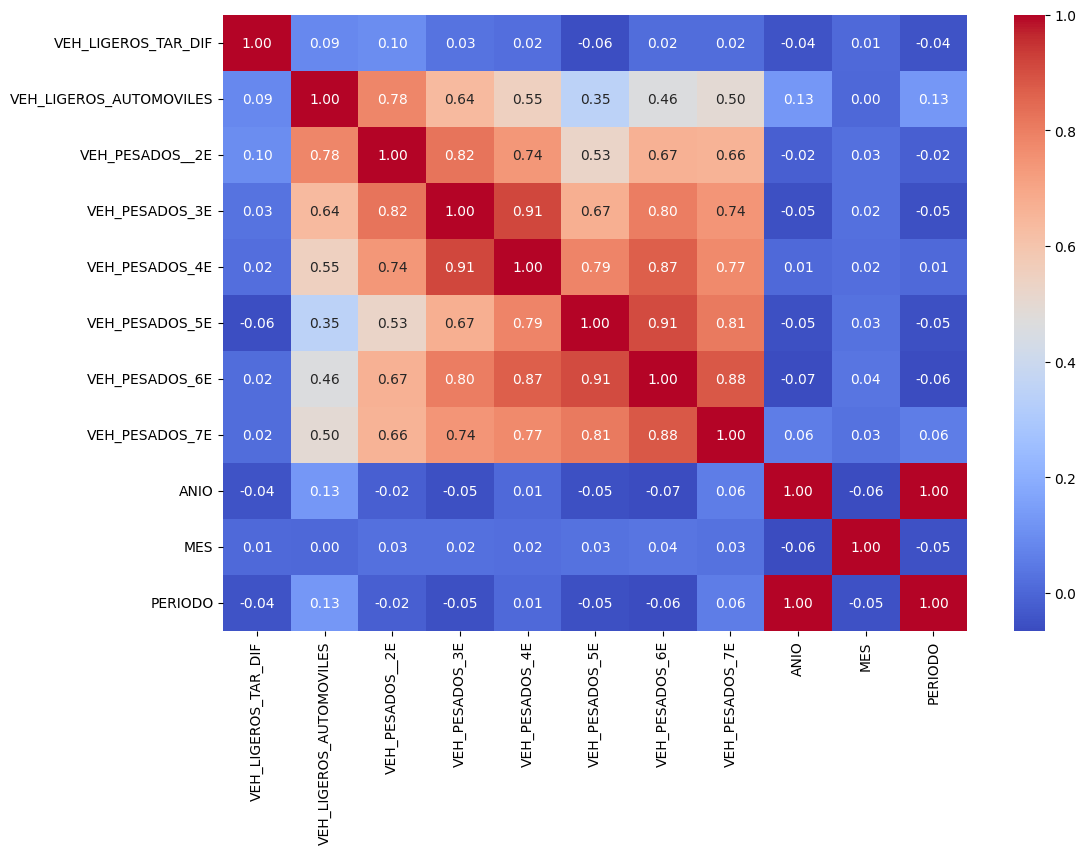

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df_num_imputed.corr()
mask = plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True
)


In [17]:
df_num_imputed

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,ANIO,MES,PERIODO
0,7.649693,8.996033,7.858254,7.772753,6.580639,5.755742,8.164226,2.197225,2014.0,1.0,201401.0
1,0.000000,10.112329,8.780019,8.438799,7.411556,8.015988,9.072457,5.365976,2014.0,1.0,201401.0
2,10.423590,11.316180,9.797127,8.576970,7.048386,7.460490,8.583543,2.564949,2014.0,1.0,201401.0
3,2.397895,10.756732,9.739909,9.830164,8.403801,8.025843,9.873080,4.912655,2014.0,1.0,201401.0
4,0.000000,10.078784,8.457443,8.279443,6.104793,6.646391,8.280458,4.564348,2014.0,1.0,201401.0
...,...,...,...,...,...,...,...,...,...,...,...
10381,6.493754,8.191463,6.695799,6.403574,6.406880,7.845416,6.756932,1.386294,2025.0,6.0,202506.0
10382,0.000000,9.636756,7.711501,6.730962,4.422817,2.864361,4.543677,0.000000,2025.0,6.0,202506.0
10383,0.000000,10.344288,8.074026,6.873164,5.673323,5.402677,6.194405,1.609438,2025.0,6.0,202506.0
10384,0.000000,9.636756,7.711501,6.730962,4.422817,2.864361,4.543677,0.000000,2025.0,6.0,202506.0


In [18]:
# Regresamos a su valor original las columnas transformadas a log1p

df_prep_num_desnorm = df_num_imputed.copy()

for col_2 in columnas_a_normalizar:
    df_prep_num_desnorm[col] = df_num_imputed[col].apply(np.expm1)

In [19]:
df_prep_num_desnorm.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,ANIO,MES,PERIODO
0,7.649693,8.996033,7.858254,7.772753,6.580639,5.755742,8.164226,8.0,2014.0,1.0,201401.0
1,0.000000,10.112329,8.780019,8.438799,7.411556,8.015988,9.072457,213.0,2014.0,1.0,201401.0
2,10.423590,11.316180,9.797127,8.576970,7.048386,7.460490,8.583543,12.0,2014.0,1.0,201401.0
3,2.397895,10.756732,9.739909,9.830164,8.403801,8.025843,9.873080,135.0,2014.0,1.0,201401.0
4,0.000000,10.078784,8.457443,8.279443,6.104793,6.646391,8.280458,95.0,2014.0,1.0,201401.0


In [20]:
df_prep_cat  

,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO
0,Concesionado,22PE5NACS1,San Martín
1,Concesionado,04PE1SCAM1,Arequipa
2,Concesionado,21PE3SCRO1,Puno
3,Concesionado,12PE3NCRA1,Junín
4,Concesionado,08PE3SCSC1,Cusco
...,...,...,...
10776,No concesionado,21PE36ASIC1,Puno
10777,No concesionado,05PE28ASOC1,Ayacucho
10778,No concesionado,20PE1NLTGD1,Piura
10779,No concesionado,15PE16TNA1,Lima


### Tratamos variables categóricas

In [27]:
from sklearn.preprocessing import OneHotEncoder

df_cat_filter = df_prep_cat.drop(columns=['CODIGO_PEAJE'])

categorical_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown= 'ignore',
    drop='first'
)
cat_encoded_array = categorical_encoder.fit_transform(df_cat_filter)

columns_cat = categorical_encoder.get_feature_names_out(df_cat_filter.columns)
df_cat_encoded = pd.DataFrame(cat_encoded_array, columns=columns_cat)

df_cat_encoded

,ADMINIST_No concesionado,DEPARTAMENTO_Apurimac,DEPARTAMENTO_Apurímac,DEPARTAMENTO_Arequipa,DEPARTAMENTO_Ayacucho,DEPARTAMENTO_Cajamarca,DEPARTAMENTO_Cusco,DEPARTAMENTO_Huánuco,DEPARTAMENTO_Ica,DEPARTAMENTO_Junín,...,DEPARTAMENTO_Lima,DEPARTAMENTO_Madre de Dios,DEPARTAMENTO_Moquegua,DEPARTAMENTO_Piura,DEPARTAMENTO_Puno,DEPARTAMENTO_San Martin,DEPARTAMENTO_San Martín,DEPARTAMENTO_Tacna,DEPARTAMENTO_Tumbes,DEPARTAMENTO_Áncash
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10381,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10382,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10383,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
10384,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
# juntamos las categorías
df_total_imputed = pd.concat([df_prep_num_desnorm, df_cat_encoded, df_prep_cat['CODIGO_PEAJE']], axis=1)

In [29]:
df_total_imputed.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,ANIO,MES,...,DEPARTAMENTO_Madre de Dios,DEPARTAMENTO_Moquegua,DEPARTAMENTO_Piura,DEPARTAMENTO_Puno,DEPARTAMENTO_San Martin,DEPARTAMENTO_San Martín,DEPARTAMENTO_Tacna,DEPARTAMENTO_Tumbes,DEPARTAMENTO_Áncash,CODIGO_PEAJE
0,7.649693,8.996033,7.858254,7.772753,6.580639,5.755742,8.164226,8.0,2014.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,22PE5NACS1
1,0.000000,10.112329,8.780019,8.438799,7.411556,8.015988,9.072457,213.0,2014.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,04PE1SCAM1
2,10.423590,11.316180,9.797127,8.576970,7.048386,7.460490,8.583543,12.0,2014.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,21PE3SCRO1
3,2.397895,10.756732,9.739909,9.830164,8.403801,8.025843,9.873080,135.0,2014.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12PE3NCRA1
4,0.000000,10.078784,8.457443,8.279443,6.104793,6.646391,8.280458,95.0,2014.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,08PE3SCSC1


In [30]:
df_total_imputed.columns

Index(['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS__2E',
       'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E',
       'VEH_PESADOS_7E', 'ANIO', 'MES', 'PERIODO', 'ADMINIST_No concesionado',
       'DEPARTAMENTO_Apurimac', 'DEPARTAMENTO_Apurímac',
       'DEPARTAMENTO_Arequipa', 'DEPARTAMENTO_Ayacucho',
       'DEPARTAMENTO_Cajamarca', 'DEPARTAMENTO_Cusco', 'DEPARTAMENTO_Huánuco',
       'DEPARTAMENTO_Ica', 'DEPARTAMENTO_Junín', 'DEPARTAMENTO_La Libertad',
       'DEPARTAMENTO_Lambayeque', 'DEPARTAMENTO_Lima',
       'DEPARTAMENTO_Madre de Dios', 'DEPARTAMENTO_Moquegua',
       'DEPARTAMENTO_Piura', 'DEPARTAMENTO_Puno', 'DEPARTAMENTO_San Martin',
       'DEPARTAMENTO_San Martín', 'DEPARTAMENTO_Tacna', 'DEPARTAMENTO_Tumbes',
       'DEPARTAMENTO_Áncash', 'CODIGO_PEAJE'],
      dtype='object')

In [31]:
df_total_imputed.to_csv('../Data/Processed/Flujo_Vehicular_procesado.csv', encoding='latin-1', index=False)